
Dataset Loaded Successfully
Dataset Shape: (6607, 20)
Columns:
 Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

Duplicate rows: 0
Dataset shape after duplicate removal: (6607, 20)
Teacher_Quality: 78 missing values filled with mode
Parental_Education_Level: 90 missing values filled with mode
Distance_from_Home: 67 missing values filled with mode

Missing values handled successfully.
Hours_Studied: 43 outliers capped
Tutoring_Sessions: 430 outliers capped

Outliers handled using IQR method.

Ordinal features encoded.
Nominal variables one-hot encoded.
Feature scaling completed.

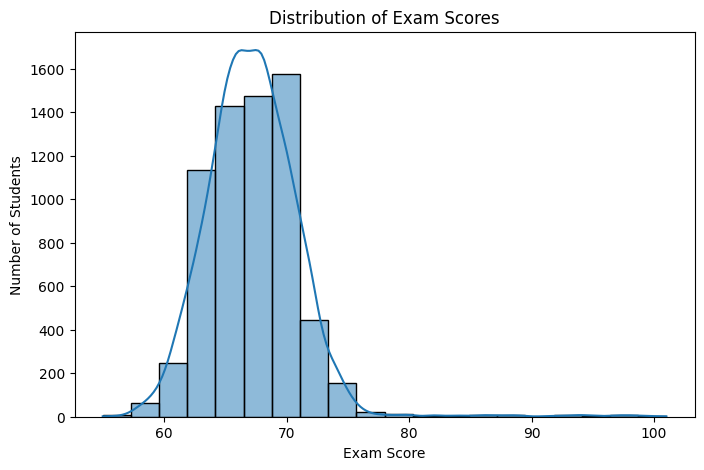

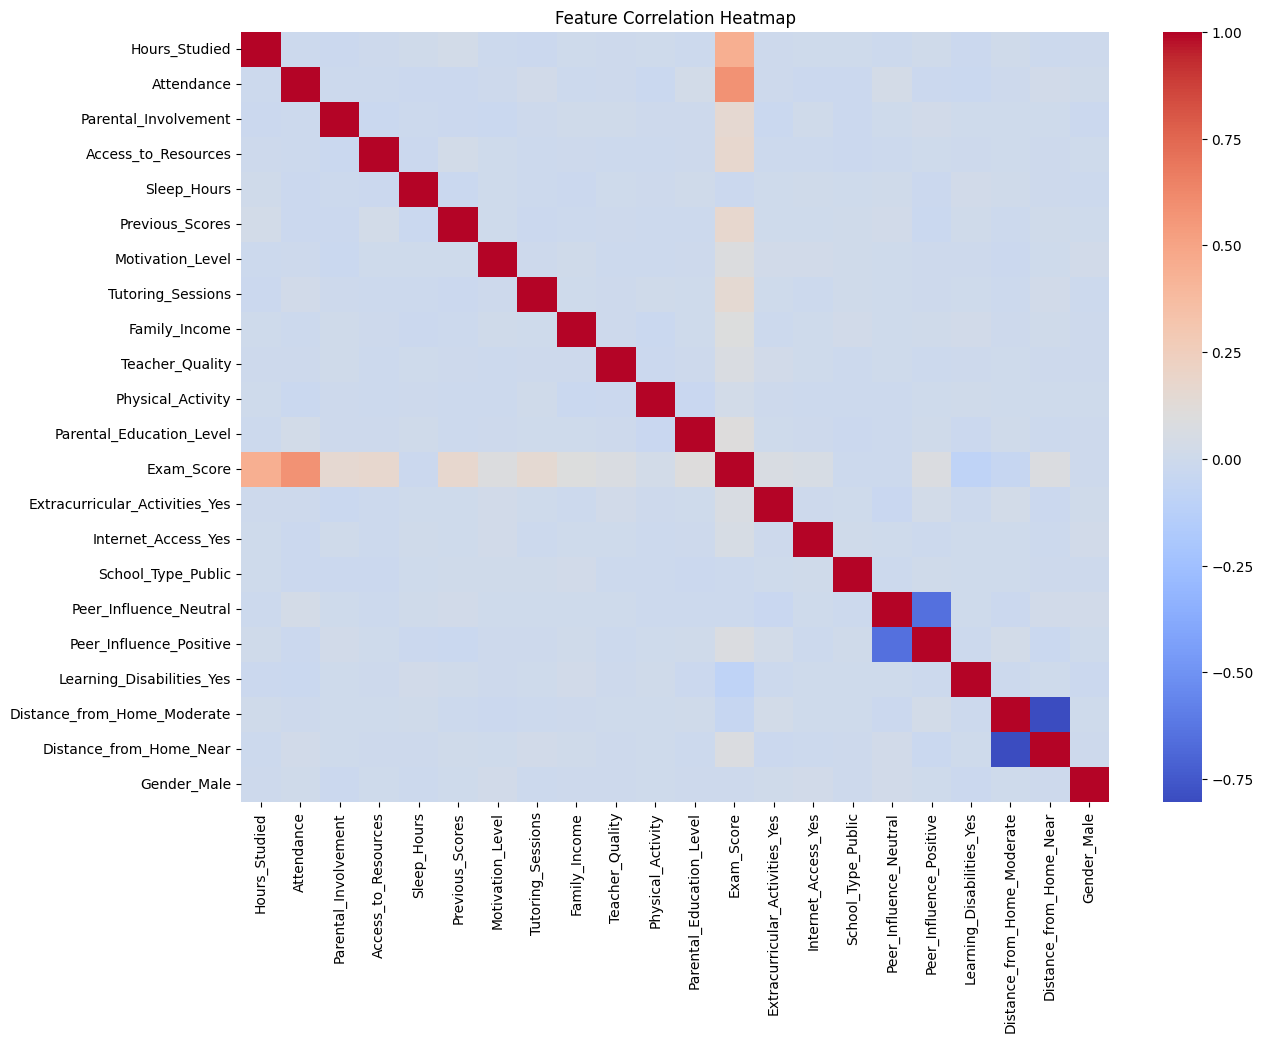

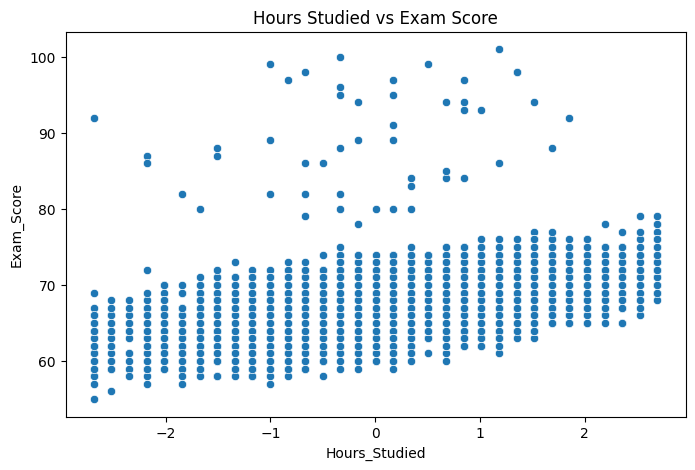

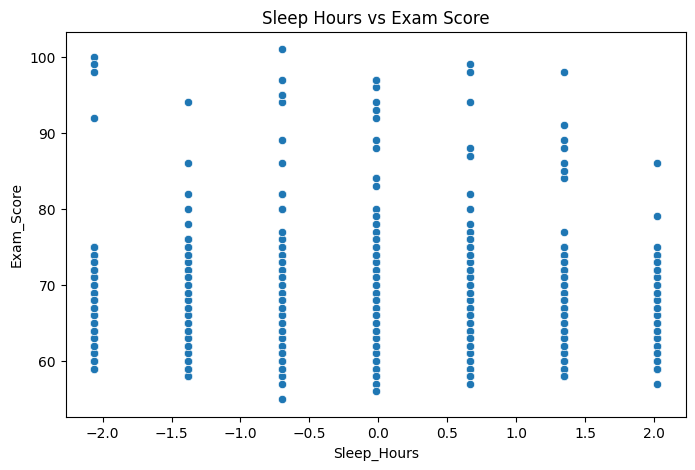

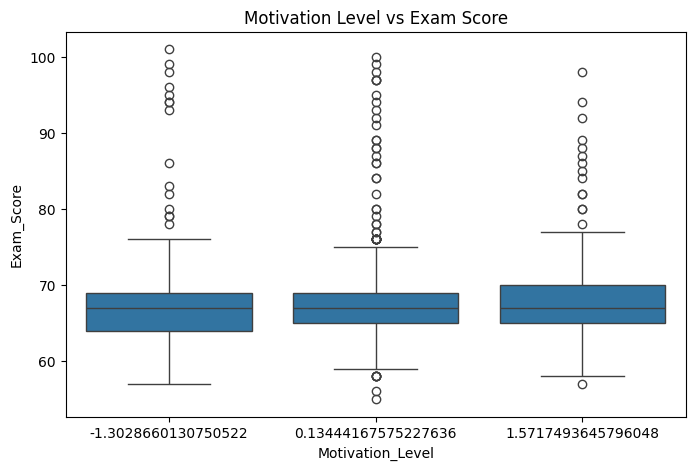


EDA visualizations generated successfully.

Clean dataset saved as: processed_student_data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. DATA COLLECTION
data_path = "StudentPerformanceFactors.csv"
df = pd.read_csv(data_path)
print("\nDataset Loaded Successfully")
print("Dataset Shape:", df.shape)
print("Columns:\n", df.columns)

# 2. CHECK & REMOVE DUPLICATES
duplicates = df.duplicated().sum()
print("\nDuplicate rows:", duplicates)
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")
print("Dataset shape after duplicate removal:", df.shape)

# 3. COLUMN CLASSIFICATION
numeric_cols = ['Hours_Studied','Attendance','Sleep_Hours','Previous_Scores','Tutoring_Sessions','Physical_Activity','Exam_Score']
ordinal_cols = ['Parental_Involvement','Access_to_Resources','Motivation_Level','Family_Income','Teacher_Quality','Parental_Education_Level']
nominal_cols = ['Extracurricular_Activities','Internet_Access','School_Type','Peer_Influence','Learning_Disabilities','Distance_from_Home','Gender']

# 4. HANDLE MISSING VALUES
for col in numeric_cols:
    missing = df[col].isna().sum()
    if missing > 0:
        print(f"{col}: {missing} missing values filled with mean")
    df[col] = df[col].fillna(df[col].mean())

for col in ordinal_cols + nominal_cols:
    missing = df[col].isna().sum()
    if missing > 0:
        print(f"{col}: {missing} missing values filled with mode")
    df[col] = df[col].fillna(df[col].mode()[0])
print("\nMissing values handled successfully.")

# 5. OUTLIER HANDLING (IQR METHOD)
numeric_features = numeric_cols[:-1]  # exclude target
for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    if outliers > 0:
        print(f"{col}: {outliers} outliers capped")
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])
print("\nOutliers handled using IQR method.")

# 6. ORDINAL ENCODING
ordinal_mappings = {
    'Parental_Involvement': {'Low':1,'Medium':2,'High':3},
    'Access_to_Resources': {'Low':1,'Medium':2,'High':3},
    'Motivation_Level': {'Low':1,'Medium':2,'High':3},
    'Family_Income': {'Low':1,'Medium':2,'High':3},
    'Teacher_Quality': {'Low':1,'Medium':2,'High':3},
    'Parental_Education_Level': {'High School':1,'College':2,'Postgraduate':3}
}
for col, mapping in ordinal_mappings.items():
    df[col] = df[col].map(mapping)
print("\nOrdinal features encoded.")

# 7. ONE HOT ENCODING
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)
print("Nominal variables one-hot encoded.")

# 8. FEATURE SCALING
scaler = StandardScaler()
features_to_scale = numeric_features + list(ordinal_mappings.keys())
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
print("Feature scaling completed.")

# 9. EXPLORATORY DATA ANALYSIS
plt.figure(figsize=(8,5))
sns.histplot(df['Exam_Score'], bins=20, kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.savefig("exam_score_distribution.png")
plt.show()

plt.figure(figsize=(14,10))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.savefig("feature_correlation_heatmap.png")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x="Hours_Studied", y="Exam_Score", data=df)
plt.title("Hours Studied vs Exam Score")
plt.savefig("hours_vs_score.png")
plt.show()

plt.figure(figsize=(8,5))
sns.scatterplot(x="Sleep_Hours", y="Exam_Score", data=df)
plt.title("Sleep Hours vs Exam Score")
plt.savefig("sleep_vs_score.png")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x="Motivation_Level", y="Exam_Score", data=df)
plt.title("Motivation Level vs Exam Score")
plt.savefig("motivation_vs_score.png")
plt.show()
print("\nEDA visualizations generated successfully.")

# 10. SAVE CLEAN DATASET
df.to_csv("processed_student_data.csv", index=False)
print("\nClean dataset saved as: processed_student_data.csv")